In [ ]:
!pip install -q opencv-python-headless albumentations mtcnn kagglehub scikit-learn matplotlib seaborn

import os
import random
import json
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

class Config:
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 25
    LEARNING_RATE = 1e-4
    NUM_FRAMES = 20
    FAKE_THRESHOLD = 0.5
    FAST_DEV_RUN = False # Set to False for full dataset training
    MAX_TRAIN_SAMPLES = 1000
    MAX_VAL_SAMPLES = 200
    MAX_TEST_SAMPLES = 300
    PROJECT_DIR = "/content/DeepFakeGuard"

CFG = Config()

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
tf.random.set_seed(CFG.SEED)

for d in ["datasets", "extracted_faces/train", "extracted_faces/val",
          "extracted_faces/test", "models", "checkpoints", "results"]:
    os.makedirs(os.path.join(CFG.PROJECT_DIR, d), exist_ok=True)

RESULTS_DIR = os.path.join(CFG.PROJECT_DIR, "results")
FACES_DIR = os.path.join(CFG.PROJECT_DIR, "extracted_faces")
CHECKPOINTS_DIR = os.path.join(CFG.PROJECT_DIR, "checkpoints")
MODELS_DIR = os.path.join(CFG.PROJECT_DIR, "models")

gpu_devices = tf.config.list_physical_devices('GPU')
for gpu in gpu_devices:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print(f"GPU Available: {bool(gpu_devices)}")
print(f"Project Directory: {CFG.PROJECT_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.9 MB/s eta 0:00:00
GPU Available: True
Project Directory: /content/DeepFakeGuard


In [ ]:
import kagglehub

KAGGLE_ID = "reubensuju/celeb-df-v2"
dataset_path = kagglehub.dataset_download(KAGGLE_ID)
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'celeb-df-v2' dataset.
Dataset downloaded to: /kaggle/input/celeb-df-v2



--- Discovered Media Files (VIDEO) ---
Total Files Found: 6529


,file_path,candidate_label
0,/kaggle/input/celeb-df-v2/YouTube-real/00238.mp4,REAL
1,/kaggle/input/celeb-df-v2/YouTube-real/00152.mp4,REAL
2,/kaggle/input/celeb-df-v2/YouTube-real/00269.mp4,REAL
3,/kaggle/input/celeb-df-v2/YouTube-real/00209.mp4,REAL
4,/kaggle/input/celeb-df-v2/YouTube-real/00297.mp4,REAL


/tmp/ipykernel_702/3411981326.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=media_df, x="candidate_label", palette="viridis")


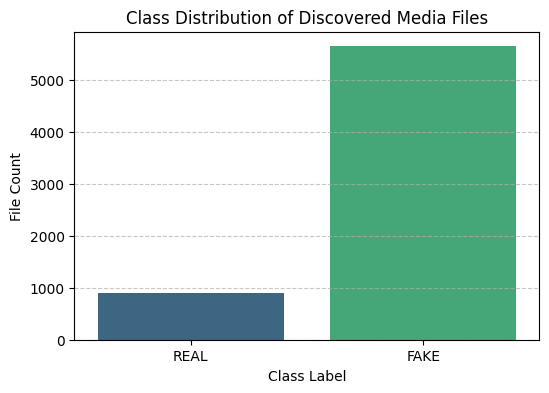

In [ ]:
import os

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".m4v"}
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}
REAL_KEYWORDS = ["real", "original", "pristine", "youtube-real", "celeb-real"]
FAKE_KEYWORDS = ["fake", "synthesis", "manipulated", "deepfake", "celeb-synthesis"]

def guess_label(path_str):
    lower = path_str.lower()
    is_real = any(k in lower for k in REAL_KEYWORDS)
    is_fake = any(k in lower for k in FAKE_KEYWORDS)
    if is_real and not is_fake:
        return "REAL"
    if is_fake and not is_real:
        return "FAKE"
    return "UNKNOWN"

def collect_media_files(root_dir, exts):
    files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if os.path.splitext(fname)[1].lower() in exts:
                files.append(os.path.join(dirpath, fname))
    return files

videos = collect_media_files(dataset_path, VIDEO_EXTS)
images = collect_media_files(dataset_path, IMAGE_EXTS)
is_video_based = len(videos) > 0
file_list = videos if is_video_based else images
media_type = "video" if is_video_based else "image"

media_df = pd.DataFrame([
    {"file_path": p, "candidate_label": guess_label(p)} for p in file_list
])

print(f"\n--- Discovered Media Files ({media_type.upper()}) ---")
print(f"Total Files Found: {len(media_df)}")
display(media_df.head())

# Class Distribution Visualization
plt.figure(figsize=(6, 4))
sns.countplot(data=media_df, x="candidate_label", palette="viridis")
plt.title("Class Distribution of Discovered Media Files")
plt.xlabel("Class Label")
plt.ylabel("File Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- Data Split Summary (Video Level) ---


label,FAKE,REAL
split,,
test,846,134
train,3947,623
val,846,133


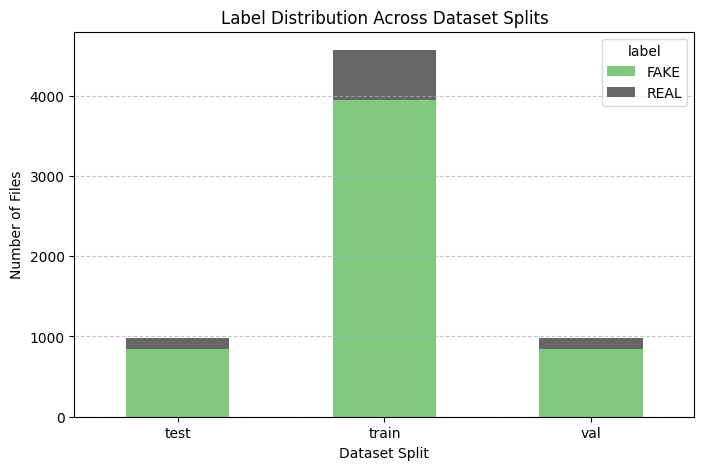

In [ ]:
def derive_video_id(file_path, media_type):
    p = Path(file_path)
    return p.stem if media_type == "video" else p.parent.name

media_df["video_id"] = media_df["file_path"].apply(lambda p: derive_video_id(p, media_type))

video_level_df = media_df.groupby("video_id").agg(
    candidate_label=("candidate_label", lambda x: x.iloc[0] if x.nunique() == 1 else "UNKNOWN"),
    sample_file_path=("file_path", "first"),
).reset_index()

known_videos_df = video_level_df[video_level_df["candidate_label"].isin(["REAL", "FAKE"])].copy()

train_videos, temp_videos = train_test_split(
    known_videos_df, test_size=0.30, stratify=known_videos_df["candidate_label"], random_state=CFG.SEED
)
val_videos, test_videos = train_test_split(
    temp_videos, test_size=0.50, stratify=temp_videos["candidate_label"], random_state=CFG.SEED
)

train_videos["split"] = "train"
val_videos["split"] = "val"
test_videos["split"] = "test"
split_assignment = pd.concat([train_videos, val_videos, test_videos])[["video_id", "split"]]

file_split_df = media_df.merge(split_assignment, on="video_id", how="inner")
file_split_df = file_split_df.rename(columns={"file_path": "video_path", "candidate_label": "label"})

split_summary = file_split_df.groupby(["split", "label"]).size().unstack(fill_value=0)
print("--- Data Split Summary (Video Level) ---")
display(split_summary)

split_summary.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Accent')
plt.title("Label Distribution Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Files")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Total raw frames extracted and saved: 30000


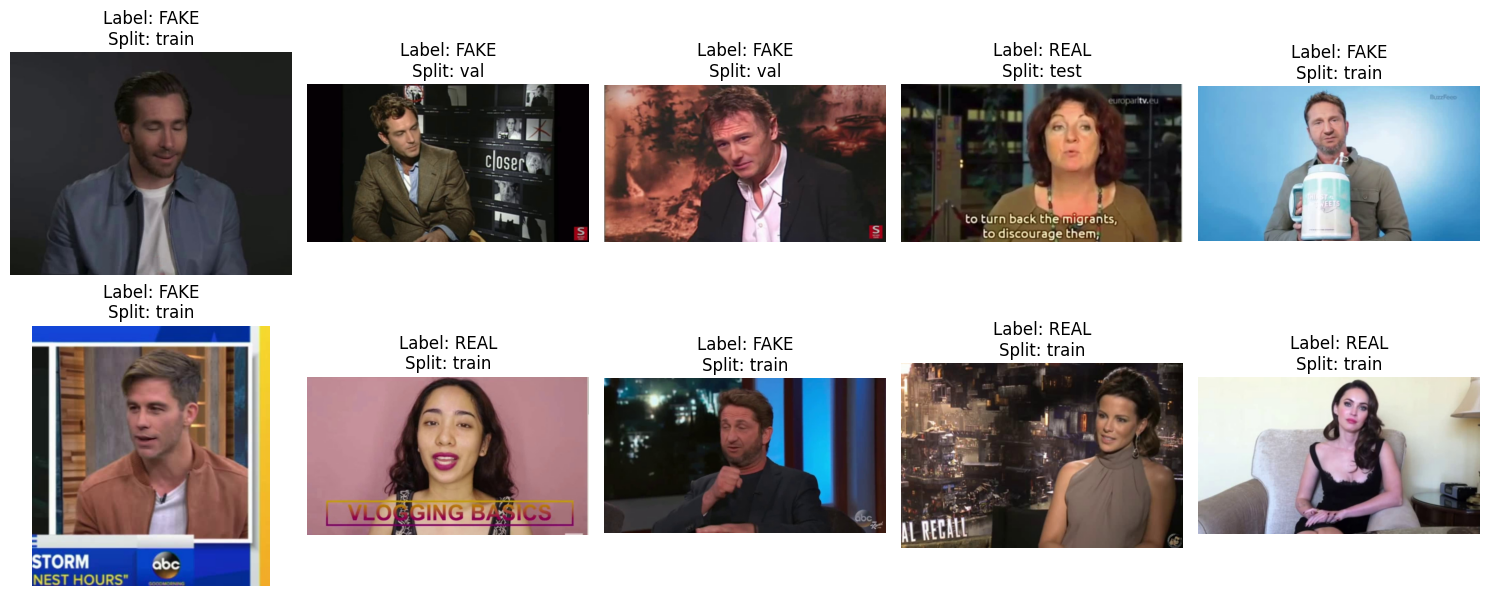

In [ ]:
def extract_frames(video_path, num_frames=CFG.NUM_FRAMES):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        return []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []
    indices = sorted(set(np.linspace(0, total_frames - 1, min(num_frames, total_frames)).astype(int)))
    extracted = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            extracted.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return extracted

def subset_split(df, max_samples):
    if CFG.FAST_DEV_RUN:
        max_samples = min(max_samples, 50)
    return df.sample(min(len(df), max_samples), random_state=CFG.SEED).reset_index(drop=True)

split_limits = {"train": CFG.MAX_TRAIN_SAMPLES, "val": CFG.MAX_VAL_SAMPLES, "test": CFG.MAX_TEST_SAMPLES}
frame_rows = []

for split_name in ["train", "val", "test"]:
    df = subset_split(file_split_df[file_split_df["split"] == split_name], split_limits[split_name])
    split_dir = os.path.join(FACES_DIR, split_name, "_raw")
    os.makedirs(split_dir, exist_ok=True)

    for _, row in df.iterrows():
        if is_video_based:
            frames = extract_frames(row["video_path"])
        else:
            img = cv2.imread(row["video_path"])
            frames = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB)] if img is not None else []

        for i, frame in enumerate(frames):
            frame_id = f"{row['video_id']}_frame{i}"
            out_path = os.path.join(split_dir, f"{frame_id}.jpg")
            cv2.imwrite(out_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            frame_rows.append({
                "video_id": row["video_id"], "frame_id": frame_id, "frame_path": out_path,
                "label": row["label"], "split": split_name,
            })

frame_df = pd.DataFrame(frame_rows)
frame_df.to_csv(os.path.join(RESULTS_DIR, "frame_metadata.csv"), index=False)
print(f"Total raw frames extracted and saved: {len(frame_df)}")

# Preview Extracted Frames
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_frames = frame_df.sample(min(10, len(frame_df)), random_state=CFG.SEED)
for ax, (_, row) in zip(axes.ravel(), sample_frames.iterrows()):
    img = cv2.imread(row["frame_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Label: {row['label']}\nSplit: {row['split']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from mtcnn import MTCNN
import albumentations as A

detector = MTCNN()
MIN_FACE_SIZE_PX = 40
FACE_MARGIN = 0.20

train_augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.3),
    A.ImageCompression(quality_lower=50, quality_upper=95, p=0.4),
    A.Affine(rotate=(-8, 8), scale=(0.95, 1.05), p=0.4),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
])

def detect_and_select_face(image_rgb):
    try:
        detections = detector.detect_faces(image_rgb)
    except Exception:
        return None
    if not detections:
        return None

    faces = []
    for d in detections:
        x, y, w, h = d["box"]
        x1, y1 = max(0, x), max(0, y)
        faces.append({"x1": x1, "y1": y1, "x2": x1 + w, "y2": y1 + h,
                       "width": w, "height": h, "confidence": d["confidence"]})

    eligible = [f for f in faces if f["width"] >= MIN_FACE_SIZE_PX and f["height"] >= MIN_FACE_SIZE_PX]
    if eligible:
        return max(eligible, key=lambda f: f["width"] * f["height"])
    return max(faces, key=lambda f: f["confidence"])

def crop_face_with_margin(image_rgb, x1, y1, x2, y2, margin=FACE_MARGIN):
    h, w = image_rgb.shape[:2]
    box_w, box_h = x2 - x1, y2 - y1
    mx, my = int(box_w * margin), int(box_h * margin)
    nx1, ny1 = max(0, x1 - mx), max(0, y1 - my)
    nx2, ny2 = min(w, x2 + mx), min(h, y2 + my)
    return image_rgb[ny1:ny2, nx1:nx2]

def preprocess_face(image_rgb, x1, y1, x2, y2, target_size=CFG.IMG_SIZE):
    crop = crop_face_with_margin(image_rgb, x1, y1, x2, y2)
    if crop.size == 0:
        return None
    return cv2.resize(crop, (target_size, target_size), interpolation=cv2.INTER_AREA)

processed_rows = []
for split_name in ["train", "val", "test"]:
    split_frames = frame_df[frame_df["split"] == split_name]
    out_dir = os.path.join(FACES_DIR, split_name)
    os.makedirs(out_dir, exist_ok=True)

    for _, row in split_frames.iterrows():
        img = cv2.imread(row["frame_path"])
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        face_box = detect_and_select_face(img_rgb)
        if face_box is None:
            continue

        face = preprocess_face(img_rgb, face_box["x1"], face_box["y1"], face_box["x2"], face_box["y2"])
        if face is None:
            continue

        clean_path = os.path.join(out_dir, f"{row['frame_id']}_clean.jpg")
        cv2.imwrite(clean_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
        processed_rows.append({"frame_id": row["frame_id"], "video_id": row["video_id"],
                                "face_path": clean_path, "label": row["label"],
                                "split": split_name, "augmented": False})

        if split_name == "train" and row["label"] == "REAL":
            for aug_idx in range(3):
                aug_face = train_augmentation(image=face)["image"]
                aug_path = os.path.join(out_dir, f"{row['frame_id']}_aug_{aug_idx}.jpg")
                cv2.imwrite(aug_path, cv2.cvtColor(aug_face, cv2.COLOR_RGB2BGR))
                processed_rows.append({"frame_id": f"{row['frame_id']}_aug_{aug_idx}", "video_id": row["video_id"],
                                        "face_path": aug_path, "label": row["label"],
                                        "split": split_name, "augmented": True})

processed_df = pd.DataFrame(processed_rows)
processed_df.to_csv(os.path.join(RESULTS_DIR, "processed_faces_metadata.csv"), index=False)

print("--- Processed Faces Metadata Summary ---")
display(processed_df.groupby(["split", "augmented"]).size().unstack(fill_value=0))

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
/tmp/ipykernel_702/1189155656.py:15: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=95, p=0.4),
/tmp/ipykernel_702/1189155656.py:17: UserWarning: Argument(s) 'var_limit' are not valid for transform

--- Processed Faces Metadata Summary ---


augmented,False,True
split,,
test,5998,0
train,19996,9111
val,3999,0


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
LABEL_MAP = {"REAL": 0, "FAKE": 1}
processed_df["label_id"] = processed_df["label"].map(LABEL_MAP)

def get_split_arrays(df, split_name):
    sub = df[df["split"] == split_name]
    return sub["face_path"].values, sub["label_id"].values.astype(np.float32)

train_paths, train_labels = get_split_arrays(processed_df, "train")
val_paths, val_labels = get_split_arrays(processed_df, "val")
test_paths, test_labels = get_split_arrays(processed_df, "test")

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [CFG.IMG_SIZE, CFG.IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def build_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(2000, len(paths)), seed=CFG.SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(CFG.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_dataset = build_dataset(train_paths, train_labels, shuffle=True)
val_dataset = build_dataset(val_paths, val_labels)
test_dataset = build_dataset(test_paths, test_labels)

print(f"Train batches: {len(train_dataset)} | Val batches: {len(val_dataset)} | Test batches: {len(test_dataset)}")

Train batches: 910 | Val batches: 125 | Test batches: 188


In [ ]:
import numpy as np
import pandas as pd

train_df = processed_df[processed_df["split"] == "train"]
fake_df = train_df[train_df["label"] == "FAKE"]
real_df = train_df[train_df["label"] == "REAL"]

min_count = min(len(fake_df), len(real_df))

balanced_train_df = pd.concat([
    fake_df.sample(min_count, random_state=CFG.SEED),
    real_df.sample(min_count, random_state=CFG.SEED)
]).sample(frac=1, random_state=CFG.SEED).reset_index(drop=True)

train_paths = balanced_train_df["face_path"].values
train_labels = balanced_train_df["label_id"].values.astype(np.float32)

train_dataset = build_dataset(train_paths, train_labels, shuffle=True)

print(f"Balanced Training Set: {len(train_paths)} total ({min_count} REAL, {min_count} FAKE)")

Balanced Training Set: 24296 total (12148 REAL, 12148 FAKE)


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

def build_model():
    inputs = layers.Input(shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3))
    x = layers.Lambda(lambda img: effnet_preprocess(img * 255.0))(inputs)
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inputs, outputs, name="deepfakeguard_balanced"), base

model, base_model = build_model()
model.summary()

train_labels_array = train_labels
class_weights_vals = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_array),
    y=train_labels_array
)
class_weight_dict = dict(enumerate(class_weights_vals))
print(f"Calculated Class Weights: {class_weight_dict}")

focal_loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True)

base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=CFG.LEARNING_RATE),
    loss=focal_loss,
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

epochs_s1 = 1 if CFG.FAST_DEV_RUN else max(5, CFG.EPOCHS // 3)
history_s1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs_s1,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True)
    ]
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

ckpt_path = os.path.join(CHECKPOINTS_DIR, "deepfakeguard_balanced_best.keras")

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=CFG.LEARNING_RATE / 10),
    loss=focal_loss,
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

epochs_s2 = 3 if CFG.FAST_DEV_RUN else CFG.EPOCHS
history_s2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs_s2,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_auc", mode="max", save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2)
    ]
)

val_y_true = np.concatenate([y.numpy() for _, y in val_dataset], axis=0)
val_y_prob = model.predict(val_dataset, verbose=0).flatten()

precisions, recalls, thresholds = precision_recall_curve(val_y_true, val_y_prob)

f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)

best_idx = np.argmax(f1_scores[:-1]) if len(thresholds) > 0 else 0
optimal_threshold = float(thresholds[best_idx]) if len(thresholds) > 0 else 0.5
CFG.FAKE_THRESHOLD = optimal_threshold

print(f"Optimal Threshold Set to: {CFG.FAKE_THRESHOLD:.4f} (Validation Max F1: {f1_scores[best_idx]:.4f})")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "deepfakeguard_balanced"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ lambda[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

Calculated Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 96s 89ms/step - accuracy: 0.5715 - auc: 0.6665 - loss: 0.0737 - val_accuracy: 0.3566 - val_auc: 0.6148 - val_loss: 0.0640
Epoch 2/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.6233 - auc: 0.7691 - loss: 0.0616 - val_accuracy: 0.4489 - val_auc: 0.6235 - val_loss: 0.0597
Epoch 3/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.6546 - auc: 0.8105 - loss: 0.0564 - val_accuracy: 0.4376 - val_auc: 0.6248 - val_loss: 0.0610
Epoch 4/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.6756 - auc: 0.8335 - loss: 0.0533 - val_accuracy: 0.4836 - val_auc: 0.6280 - val_loss: 0.0590
Epoch 5/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.6878 - auc: 0.8483 - loss: 0.0515 - val_accuracy: 0.5016 - val_auc: 0.6303 - val_loss: 0.0586
Epoch 6/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.6985 - auc: 0.8572 - loss: 0.0501 - val_accuracy: 0.5084 - va

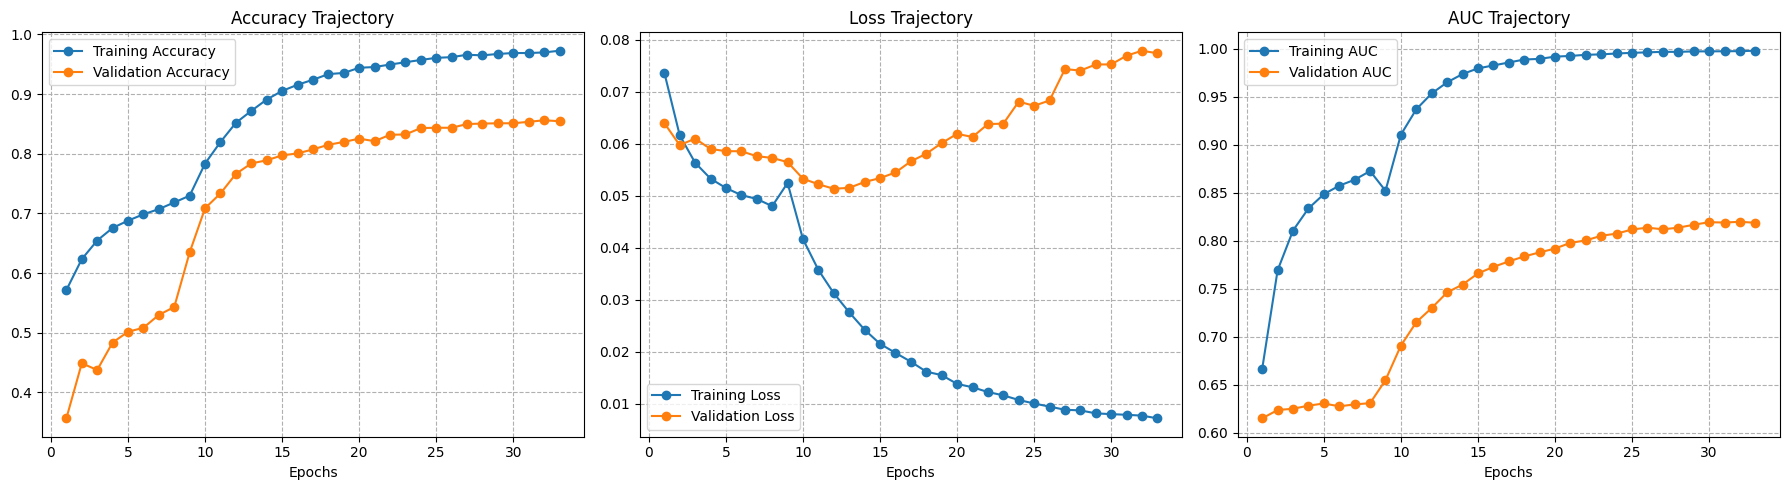

In [ ]:
def combine_histories(h1, h2, metric):
    v1 = h1.history.get(metric, [])
    v2 = h2.history.get(metric, [])
    return v1 + v2

acc = combine_histories(history_s1, history_s2, 'accuracy')
val_acc = combine_histories(history_s1, history_s2, 'val_accuracy')
loss = combine_histories(history_s1, history_s2, 'loss')
val_loss = combine_histories(history_s1, history_s2, 'val_loss')
auc = combine_histories(history_s1, history_s2, 'auc')
val_auc = combine_histories(history_s1, history_s2, 'val_auc')

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy Plot
axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o')
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
axes[0].set_title('Accuracy Trajectory')
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(True, linestyle='--')

# Loss Plot
axes[1].plot(epochs_range, loss, label='Training Loss', marker='o')
axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='o')
axes[1].set_title('Loss Trajectory')
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(True, linestyle='--')

# AUC Plot
axes[2].plot(epochs_range, auc, label='Training AUC', marker='o')
axes[2].plot(epochs_range, val_auc, label='Validation AUC', marker='o')
axes[2].set_title('AUC Trajectory')
axes[2].set_xlabel('Epochs')
axes[2].legend()
axes[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

--- Final Evaluation Metrics (Test Set) ---
{
  "accuracy": 0.8926,
  "precision": 0.9015,
  "recall": 0.9862,
  "f1": 0.942,
  "roc_auc": 0.8155
}
Model saved to: /content/DeepFakeGuard/models/final_model.keras


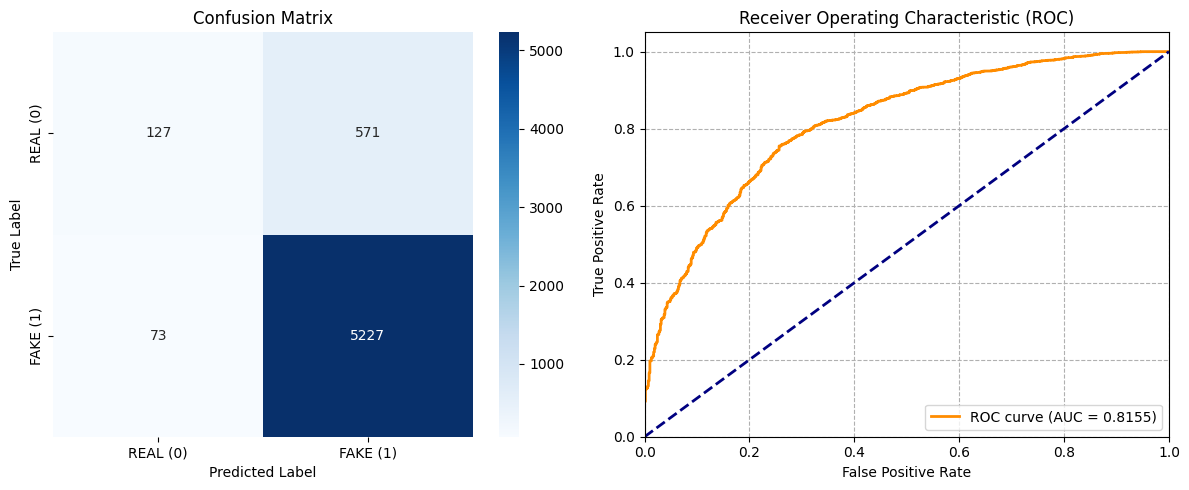

In [ ]:
y_true, y_prob = [], []
for imgs, labels in test_dataset:
    y_prob.extend(model.predict(imgs, verbose=0).flatten())
    y_true.extend(labels.numpy())

y_true, y_prob = np.array(y_true), np.array(y_prob)
y_pred = (y_prob >= CFG.FAKE_THRESHOLD).astype(int)

metrics = {
    "accuracy": round(accuracy_score(y_true, y_pred), 4),
    "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
    "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
    "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    "roc_auc": round(roc_auc_score(y_true, y_prob), 4) if len(set(y_true)) > 1 else None,
}

print("--- Final Evaluation Metrics (Test Set) ---")
print(json.dumps(metrics, indent=2))

with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

final_model_path = os.path.join(MODELS_DIR, "final_model.keras")
model.save(final_model_path)
print(f"Model saved to: {final_model_path}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['REAL (0)', 'FAKE (1)'],
            yticklabels=['REAL (0)', 'FAKE (1)'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

if len(set(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {metrics["roc_auc"]})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic (ROC)')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

--- Single Image Inference Result ---
Prediction: FAKE
Confidence: 0.9002
Raw Fake Probability: 0.9002


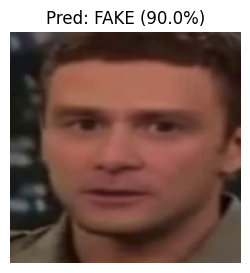

In [ ]:
def analyze_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return {"error": "Could not read image."}
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face_box = detect_and_select_face(img_rgb)
    if face_box is None:
        return {"error": "No face detected."}

    face = preprocess_face(img_rgb, face_box["x1"], face_box["y1"], face_box["x2"], face_box["y2"])
    if face is None:
        return {"error": "Face crop failed."}

    img_batch = np.expand_dims(face.astype(np.float32) / 255.0, axis=0)
    prob = float(model.predict(img_batch, verbose=0)[0][0])
    prediction = "FAKE" if prob >= CFG.FAKE_THRESHOLD else "REAL"
    confidence = prob if prediction == "FAKE" else 1 - prob

    return {
        "prediction": prediction,
        "confidence": round(confidence, 4),
        "raw_fake_probability": round(prob, 4),
        "face_image": face
    }

def analyze_video(video_path, num_frames=CFG.NUM_FRAMES):
    frames = extract_frames(video_path, num_frames=num_frames)
    if not frames:
        return {"error": "Could not extract frames."}

    probs = []
    for frame in frames:
        face_box = detect_and_select_face(frame)
        if face_box is None:
            continue
        face = preprocess_face(frame, face_box["x1"], face_box["y1"], face_box["x2"], face_box["y2"])
        if face is None:
            continue
        img_batch = np.expand_dims(face.astype(np.float32) / 255.0, axis=0)
        probs.append(float(model.predict(img_batch, verbose=0)[0][0]))

    if not probs:
        return {"error": "No faces detected in any sampled frame."}

    avg_prob = float(np.mean(probs))
    prediction = "FAKE" if avg_prob >= CFG.FAKE_THRESHOLD else "REAL"
    confidence = avg_prob if prediction == "FAKE" else 1 - avg_prob

    return {
        "prediction": prediction,
        "confidence": round(confidence, 4),
        "frames_with_face": len(probs),
        "frames_analyzed": len(frames)
    }

# Test Inference on a Sample Face
if len(processed_df) > 0:
    sample_img_path = processed_df.iloc[0]["face_path"]
    res = analyze_image(sample_img_path)

    print("--- Single Image Inference Result ---")
    print(f"Prediction: {res.get('prediction')}")
    print(f"Confidence: {res.get('confidence')}")
    print(f"Raw Fake Probability: {res.get('raw_fake_probability')}")

    if "face_image" in res:
        plt.figure(figsize=(3, 3))
        plt.imshow(res["face_image"])
        plt.title(f"Pred: {res['prediction']} ({res['confidence']*100:.1f}%)")
        plt.axis("off")
        plt.show()